# Elements AJIVE Analysis

This notebook:
1. Builds the multi-element synthetic dataset used for task1/task2.
2. Prints class balance for both tasks (shape and texture majorities).
3. Loads two trained networks (task1: shape, task2: texture).
4. Extracts train/val/test features and logits.
5. Runs AJIVE and compares downstream classification performance on different feature projections.

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix

from src import Single_Element_Dataloader, Single_view_model

sys.path.insert(0, os.path.abspath('python_packages'))
from python_packages import *

In [3]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
device

'mps'

## Dataset Configuration

In [36]:
dataset_cfg = {
    'batch_size': 64,
    'num_workers': 4,
    'n_train': 5000,
    'n_val': 1000,
    'n_test': 1000,
    'img_size': 224,
    'element_n': 9,
    'element_size': 24,
    'element_size_delta': 8,
    'allowed_shapes': ['square', 'circle', 'triangle', 'plus'],
    'allowed_colors': ['red', 'green', 'blue'],
    'allowed_textures': ['solid', 'spots_polka', 'stripes_diagonal'],
    'element_seed': 42,
    'loc_seed': 123,
    'max_resample_attempt_factor': 50,
    'train_transform': None,
    'transform': None,
    'use_train_sampler': False,
    'sampler_target': 'shape',
}

dataloader = Single_Element_Dataloader(**dataset_cfg)

1 2


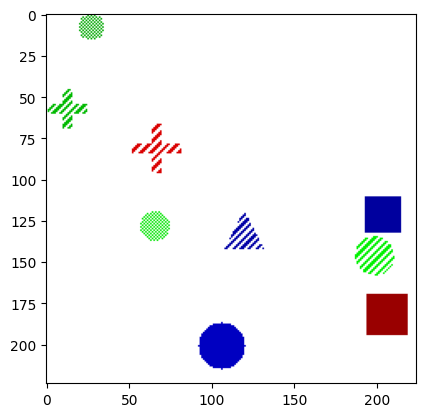

In [37]:
ind = 4
plt.imshow(dataloader.train_dataset[ind][0].permute(1, 2, 0))
print(dataloader.train_dataset[ind][1], dataloader.train_dataset[ind][2])

## Class Balance Print (Requested)

In [38]:
def _print_balance_counts(labels, class_names, title):
    counts = np.bincount(labels, minlength=len(class_names))
    freq = counts / counts.sum()
    print(f'\n{title}')
    print('-' * len(title))
    for idx, name in enumerate(class_names):
        print(f'  {idx}: {name:16s} count={counts[idx]:5d}  frac={freq[idx]:.4f}')


def print_class_balance(single_element_loader):
    shape_names = single_element_loader.train_dataset.allowed_shapes
    texture_names = single_element_loader.train_dataset.allowed_textures

    split_datasets = {
        'train': single_element_loader.train_dataset,
        'val': single_element_loader.val_dataset,
        'test': single_element_loader.test_dataset,
    }

    for split_name, split_ds in split_datasets.items():
        print(f'\n================= {split_name.upper()} =================')
        _print_balance_counts(split_ds.shape_labels, shape_names, 'Task1 majority shape')
        _print_balance_counts(split_ds.texture_labels, texture_names, 'Task2 majority texture')


print_class_balance(dataloader)


================= TRAIN =================

Task1 majority shape
--------------------
  0: square           count= 1248  frac=0.2496
  1: circle           count= 1297  frac=0.2594
  2: triangle         count= 1222  frac=0.2444
  3: plus             count= 1233  frac=0.2466

Task2 majority texture
----------------------
  0: solid            count= 1689  frac=0.3378
  1: spots_polka      count= 1651  frac=0.3302
  2: stripes_diagonal count= 1660  frac=0.3320

================= VAL =================

Task1 majority shape
--------------------
  0: square           count=  273  frac=0.2730
  1: circle           count=  240  frac=0.2400
  2: triangle         count=  237  frac=0.2370
  3: plus             count=  250  frac=0.2500

Task2 majority texture
----------------------
  0: solid            count=  336  frac=0.3360
  1: spots_polka      count=  325  frac=0.3250
  2: stripes_diagonal count=  339  frac=0.3390

================= TEST =================

Task1 majority shape
--------------

## Load Trained Task Models

Update checkpoint paths to your task1/task2 trained models from `train_elements.py`.

In [39]:
shape_ckpt_path = 'artifacts/model-908ij4rg:v0/model.ckpt'
texture_ckpt_path = 'artifacts/model-qtzv9eop:v0/model.ckpt'

for p in [shape_ckpt_path, texture_ckpt_path]:
    if not Path(p).exists():
        print(f'WARNING: checkpoint not found -> {p}')

In [40]:
model_shape = Single_view_model.load_from_checkpoint(shape_ckpt_path, map_location='cpu')
model_texture = Single_view_model.load_from_checkpoint(texture_ckpt_path, map_location='cpu')

model_shape = model_shape.to(device).eval()
model_texture = model_texture.to(device).eval()

print('Loaded models:')
print('  shape model task:', model_shape.task)
print('  texture model task:', model_texture.task)

Loaded models:
  shape model task: 1
  texture model task: 2


## Feature Extraction Helpers

In [17]:
def get_featurized_data(loader, shape_model, texture_model, device):
    shape_model.eval()
    texture_model.eval()

    all_shape_features = []
    all_texture_features = []
    all_shape_logits = []
    all_texture_logits = []
    all_shape_labels = []
    all_texture_labels = []

    with torch.no_grad():
        for batch in tqdm.tqdm(loader, desc='Featurizing split'):
            x, y_shape, y_texture = batch
            x = x.to(device)

            shape_resnet_out = shape_model.get_resnet_outputs(x)
            texture_resnet_out = texture_model.get_resnet_outputs(x)

            shape_logits = shape_model.fc(shape_model.resnet.fc(shape_resnet_out))
            texture_logits = texture_model.fc(texture_model.resnet.fc(texture_resnet_out))

            all_shape_features.append(shape_resnet_out.cpu())
            all_texture_features.append(texture_resnet_out.cpu())
            all_shape_logits.append(shape_logits.cpu())
            all_texture_logits.append(texture_logits.cpu())
            all_shape_labels.append(y_shape.cpu())
            all_texture_labels.append(y_texture.cpu())

    return {
        'shape_features': torch.cat(all_shape_features, dim=0).numpy(),
        'texture_features': torch.cat(all_texture_features, dim=0).numpy(),
        'shape_logits': torch.cat(all_shape_logits, dim=0).numpy(),
        'texture_logits': torch.cat(all_texture_logits, dim=0).numpy(),
        'shape_labels': torch.cat(all_shape_labels, dim=0).numpy(),
        'texture_labels': torch.cat(all_texture_labels, dim=0).numpy(),
    }

In [ ]:
# Cache extracted feature splits to avoid recomputation in future runs
USE_CACHED_FEATURES = False  # Set True to load cached .pt files if they exist

cache_dir = Path('saved_features/Elements_AJIVE')
cache_dir.mkdir(parents=True, exist_ok=True)

cache_paths = {
    'train': cache_dir / 'all_data_train.pt',
    'val': cache_dir / 'all_data_val.pt',
    'test': cache_dir / 'all_data_test.pt',
}

cache_available = all(path.exists() for path in cache_paths.values())

if USE_CACHED_FEATURES and cache_available:
    train_data = torch.load(cache_paths['train'], weights_only=False)
    val_data = torch.load(cache_paths['val'], weights_only=False)
    test_data = torch.load(cache_paths['test'], weights_only=False)
    print('Loaded cached features from:', cache_dir)
else:
    train_data = get_featurized_data(dataloader.train_dataloader(), model_shape, model_texture, device)
    val_data = get_featurized_data(dataloader.val_dataloader(), model_shape, model_texture, device)
    test_data = get_featurized_data(dataloader.test_dataloader(), model_shape, model_texture, device)

    torch.save(train_data, cache_paths['train'])
    torch.save(val_data, cache_paths['val'])
    torch.save(test_data, cache_paths['test'])
    print('Saved feature caches to:', cache_dir)

for split_name, split_data in [('train', train_data), ('val', val_data), ('test', test_data)]:
    print(f"{split_name}: shape_features={split_data['shape_features'].shape}, texture_features={split_data['texture_features'].shape}")

Featurizing split:   0%|          | 0/79 [00:00<?, ?it/s]

## AJIVE on Task1/Task2 Features

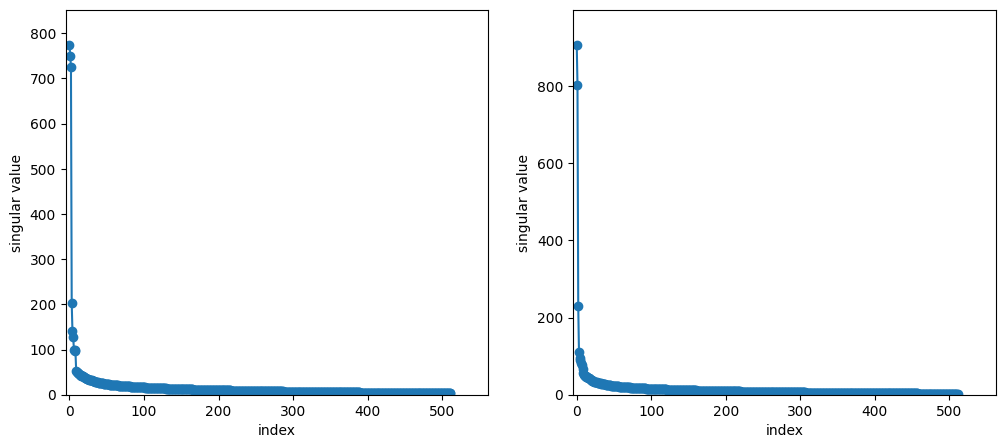

In [26]:
plt.figure(figsize=[12, 5])
plt.subplot(1, 2, 1)
PCA().fit(train_data['shape_features']).plot_scree(log = False)
plt.subplot(1, 2, 2)
PCA().fit(train_data['texture_features']).plot_scree(log = False)

In [30]:
aj = AJIVE(init_signal_ranks=(14, 14), n_jobs=4, center=True)
aj.fit([train_data['shape_features'], train_data['texture_features']])
aj.summary()

'AJIVE, joint rank: 3, view 0 indiv rank: 11, view 1 indiv rank: 11'

In [31]:
def get_ajive_projections(aj_model, train_split, val_split, test_split):
    train_shape_joint = aj_model.view_specific_[0].joint_.transform(train_split['shape_features'])
    val_shape_joint = aj_model.view_specific_[0].joint_.transform(val_split['shape_features'])
    test_shape_joint = aj_model.view_specific_[0].joint_.transform(test_split['shape_features'])

    train_shape_indiv = aj_model.view_specific_[0].individual_.transform(train_split['shape_features'])
    val_shape_indiv = aj_model.view_specific_[0].individual_.transform(val_split['shape_features'])
    test_shape_indiv = aj_model.view_specific_[0].individual_.transform(test_split['shape_features'])

    train_texture_joint = aj_model.view_specific_[1].joint_.transform(train_split['texture_features'])
    val_texture_joint = aj_model.view_specific_[1].joint_.transform(val_split['texture_features'])
    test_texture_joint = aj_model.view_specific_[1].joint_.transform(test_split['texture_features'])

    train_texture_indiv = aj_model.view_specific_[1].individual_.transform(train_split['texture_features'])
    val_texture_indiv = aj_model.view_specific_[1].individual_.transform(val_split['texture_features'])
    test_texture_indiv = aj_model.view_specific_[1].individual_.transform(test_split['texture_features'])

    projections = {
        'shape_original': (train_split['shape_features'], val_split['shape_features'], test_split['shape_features']),
        'shape_joint': (train_shape_joint, val_shape_joint, test_shape_joint),
        'shape_individual': (train_shape_indiv, val_shape_indiv, test_shape_indiv),
        'texture_original': (train_split['texture_features'], val_split['texture_features'], test_split['texture_features']),
        'texture_joint': (train_texture_joint, val_texture_joint, test_texture_joint),
        'texture_individual': (train_texture_indiv, val_texture_indiv, test_texture_indiv),
    }
    return projections

In [32]:
projections = get_ajive_projections(aj, train_data, val_data, test_data)
{k: (v[0].shape, v[1].shape, v[2].shape) for k, v in projections.items()}

{'shape_original': ((5000, 512), (1000, 512), (1000, 512)),
 'shape_joint': ((5000, 3), (1000, 3), (1000, 3)),
 'shape_individual': ((5000, 11), (1000, 11), (1000, 11)),
 'texture_original': ((5000, 512), (1000, 512), (1000, 512)),
 'texture_joint': ((5000, 3), (1000, 3), (1000, 3)),
 'texture_individual': ((5000, 11), (1000, 11), (1000, 11))}

## Linear Probe with RBF SVM

In [33]:
def evaluate_svm_classifier(X_train, y_train, X_val, y_val, X_test, y_test, feature_name):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(kernel='rbf', probability=True, random_state=42)
    clf.fit(X_train_scaled, y_train)

    test_pred = clf.predict(X_test_scaled)
    return {
        'feature_name': feature_name,
        'feature_dims': X_train.shape[1],
        'test_acc_macro': balanced_accuracy_score(y_test, test_pred),
        'test_f1_macro': f1_score(y_test, test_pred, average='macro'),
        'confusion_matrix': confusion_matrix(y_test, test_pred),
    }


def evaluate_projection_family(proj_dict, labels_train, labels_val, labels_test, prefix):
    rows = []
    for name, (X_train, X_val, X_test) in proj_dict.items():
        if not name.startswith(prefix):
            continue
        row = evaluate_svm_classifier(
            X_train, labels_train,
            X_val, labels_val,
            X_test, labels_test,
            feature_name=name,
        )
        rows.append(row)
    return pd.DataFrame(rows).sort_values('test_f1_macro', ascending=False)

In [34]:
shape_results = evaluate_projection_family(
    projections,
    train_data['shape_labels'],
    val_data['shape_labels'],
    test_data['shape_labels'],
    prefix='shape_',
)

texture_results = evaluate_projection_family(
    projections,
    train_data['texture_labels'],
    val_data['texture_labels'],
    test_data['texture_labels'],
    prefix='texture_',
)

print('Shape task results')
display(shape_results[['feature_name', 'feature_dims', 'test_acc_macro', 'test_f1_macro']])

print('Texture task results')
display(texture_results[['feature_name', 'feature_dims', 'test_acc_macro', 'test_f1_macro']])

Shape task results


,feature_name,feature_dims,test_acc_macro,test_f1_macro
0,shape_original,512,1.0,1.0
1,shape_joint,3,1.0,1.0
2,shape_individual,11,1.0,1.0


Texture task results


,feature_name,feature_dims,test_acc_macro,test_f1_macro
0,texture_original,512,0.999034,0.999003
1,texture_joint,3,0.999034,0.999003
2,texture_individual,11,0.998005,0.998005
